# Threshold Calibration

This notebook runs calibration, shows percentile distributions, validates economic plausibility, and plots threshold boundaries on data.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Add src to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / "src"))

from src.data_acquisition.downloader import MarketDataDownloader
from src.data_acquisition.preprocessor import DataPreprocessor
from src.feature_engineering.technical_features import TechnicalFeatureComputer
from src.feature_engineering.calibrator import ThresholdCalibrator

In [2]:
# Download calibration data (2000-2015)
downloader = MarketDataDownloader()
data = downloader.get_combined_data("^GSPC", "2000-01-01", "2015-12-31", "US")

# Preprocess
preprocessor = DataPreprocessor()
data_clean = preprocessor.clean(data)

# Compute features
feature_computer = TechnicalFeatureComputer()
features = feature_computer.compute_all_features(data_clean)

print(f"Computed features for {len(features)} days")

Computed features for 3994 days


In [3]:
# Calibrate thresholds
calibrator = ThresholdCalibrator()
thresholds = calibrator.calibrate(features)

print("Calibrated thresholds:")
for feature_name, thresh_dict in thresholds.items():
    print(f"\n{feature_name}:")
    for p, value in thresh_dict.items():
        print(f"  {p}: {value:.4f}")

Calibrated thresholds:

rolling_return:
  p10: -0.0638
  p25: -0.0228
  p40: -0.0002
  p70: 0.0327
  p75: 0.0385
  p80: 0.0447
  p90: 0.0635

rolling_volatility:
  p10: 0.0056
  p25: 0.0067
  p40: 0.0080
  p70: 0.0119
  p75: 0.0134
  p80: 0.0144
  p90: 0.0180

price_slope:
  p10: -2.9797
  p25: -1.2480
  p40: 0.0410
  p70: 1.5507
  p75: 1.8166
  p80: 2.0861
  p90: 2.7861

volume_trend:
  p10: -0.1856
  p25: -0.0952
  p40: -0.0392
  p70: 0.0754
  p75: 0.1012
  p80: 0.1288
  p90: 0.2152

vix:
  p10: 12.3600
  p25: 14.3325
  p40: 16.7000
  p70: 22.7200
  p75: 24.1475
  p80: 25.6100
  p90: 31.0170


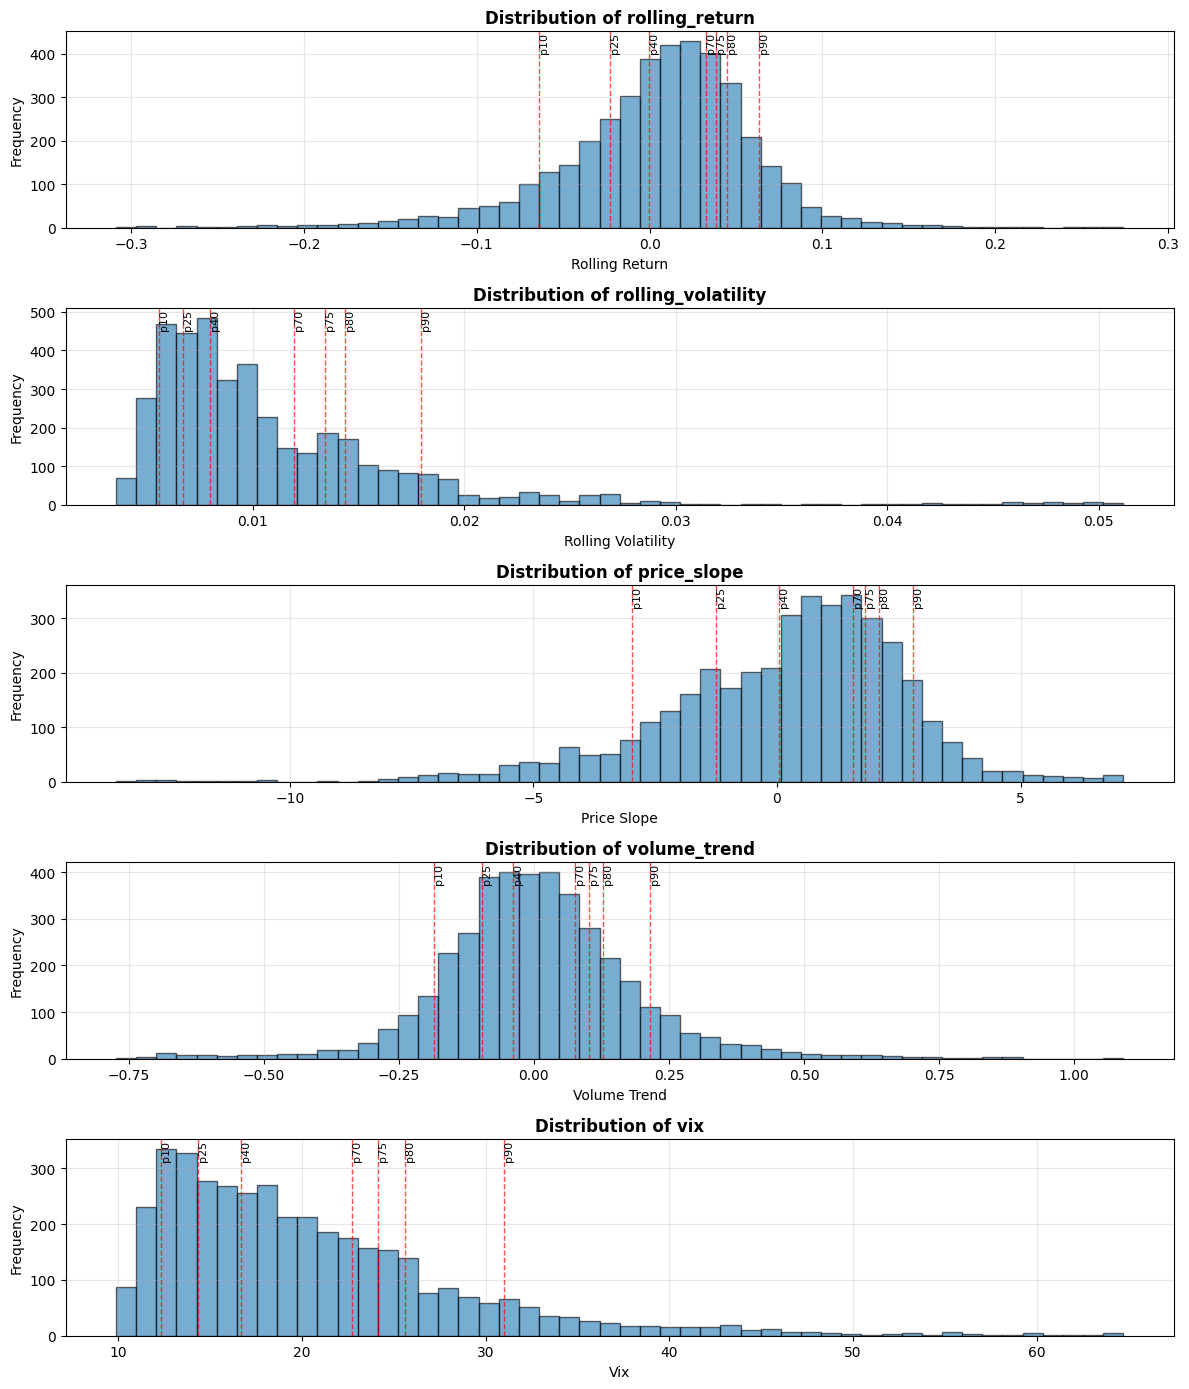

In [4]:
# Plot percentile distributions
feature_cols = ['rolling_return', 'rolling_volatility', 'price_slope', 'volume_trend', 'vix']

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(12, 14))

for i, col in enumerate(feature_cols):
    ax = axes[i]
    
    # Histogram
    ax.hist(features[col].dropna(), bins=50, alpha=0.6, edgecolor='black')
    
    # Mark percentiles
    thresh = thresholds[col]
    for p_name, p_value in thresh.items():
        ax.axvline(x=p_value, color='red', linestyle='--', alpha=0.7, linewidth=1)
        ax.text(p_value, ax.get_ylim()[1] * 0.9, p_name, rotation=90, fontsize=8)
    
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/calibration_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Validate economic plausibility
try:
    calibrator.validate_economic_plausibility(thresholds)
    print("✓ Thresholds pass economic plausibility checks")
except ValueError as e:
    print(f"✗ Validation failed: {e}")

✓ Thresholds pass economic plausibility checks
